In [124]:
# Migration and Remittances

import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('images', exist_ok=True)

url = "https://api.worldbank.org/v2/country/all/indicator/BX.TRF.PWKR.DT.GD.ZS?format=json&per_page=20000"

response = requests.get(url)
data = response.json()

records = data[1]

rows = []

for item in records:
    rows.append({
        "country": item["country"]["value"],
        "year": item["date"],
        "remittance_pct_gdp": item["value"]
    })

df = pd.DataFrame(rows)

df.head()

df = df.dropna()

df["year"] = df["year"].astype(int)

df.head()

latest = df[df["year"] == 2023]

top10 = latest.sort_values(
    by="remittance_pct_gdp",
    ascending=False
).head(10)

print(top10)

           country  year  remittance_pct_gdp
16106        Tonga  2023           42.610422
15776   Tajikistan  2023           37.844578
10496      Lebanon  2023           33.349773
12344        Nepal  2023           26.224109
12608    Nicaragua  2023           26.184103
8846      Honduras  2023           26.103904
13994        Samoa  2023           25.354728
7130   El Salvador  2023           24.478374
4622       Bermuda  2023           23.723756
6074       Comoros  2023           23.030370


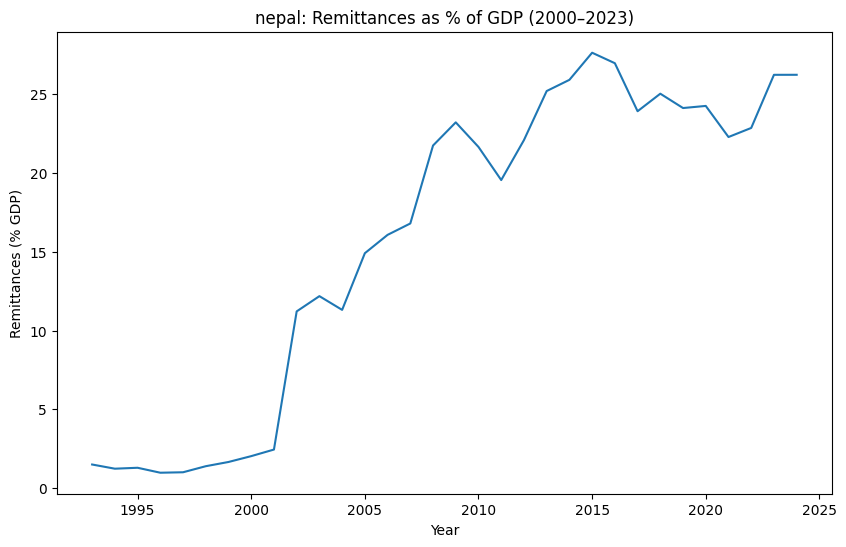

In [125]:
nepal = df[df["country"] == "Nepal"]

plt.figure(figsize=(10,6))
plt.plot(nepal["year"], nepal["remittance_pct_gdp"])

plt.title("nepal: Remittances as % of GDP (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Remittances (% GDP)")
plt.savefig('images/nepal_remittances_as_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

In [126]:
import pandas as pd
import requests

# -------------------------
# REMITTANCES (US$)
# -------------------------

url_remit = "https://api.worldbank.org/v2/country/all/indicator/BX.TRF.PWKR.CD.DT?format=json&per_page=20000"

remit_data = requests.get(url_remit).json()

remit_rows = []

for item in remit_data[1]:
    remit_rows.append({
        "country": item["country"]["value"],
        "year": item["date"],
        "remittances_usd": item["value"]
    })

remit_df = pd.DataFrame(remit_rows)

remit_df = remit_df.dropna()
remit_df["year"] = remit_df["year"].astype(int)

# -------------------------
# FOREIGN AID (US$)
# -------------------------

url_aid = "https://api.worldbank.org/v2/country/all/indicator/DT.ODA.ODAT.CD?format=json&per_page=20000"

aid_data = requests.get(url_aid).json()

aid_rows = []

for item in aid_data[1]:
    aid_rows.append({
        "country": item["country"]["value"],
        "year": item["date"],
        "aid_usd": item["value"]
    })

aid_df = pd.DataFrame(aid_rows)

aid_df = aid_df.dropna()
aid_df["year"] = aid_df["year"].astype(int)

# -------------------------
# MERGE DATASETS
# -------------------------

merged = pd.merge(
    remit_df,
    aid_df,
    on=["country", "year"],
    how="inner"
)

# -------------------------
# SELECT COUNTRIES
# -------------------------

countries = [
    "Nepal",
    "Tajikistan",
    "Honduras",
    "El Salvador"
]

latest = merged[
    (merged["country"].isin(countries))
    & (merged["year"] == 2023)
].copy()

# -------------------------
# CALCULATE RATIO
# -------------------------

latest["remittance_to_aid_ratio"] = (
    latest["remittances_usd"] /
    latest["aid_usd"]
)

# -------------------------
# FORMAT TABLE
# -------------------------

latest = latest[
    [
        "country",
        "year",
        "remittances_usd",
        "aid_usd",
        "remittance_to_aid_ratio"
    ]
]

latest = latest.sort_values(
    "remittance_to_aid_ratio",
    ascending=False
)

print(latest)

          country  year  remittances_usd       aid_usd  \
3871  El Salvador  2023     8.286894e+09  4.988104e+08   
4444     Honduras  2023     8.968206e+09  5.507666e+08   
5684        Nepal  2023     1.076441e+10  1.173137e+09   
6843   Tajikistan  2023     4.633754e+09  5.307999e+08   

      remittance_to_aid_ratio  
3871                16.613314  
4444                16.283134  
5684                 9.175752  
6843                 8.729758  


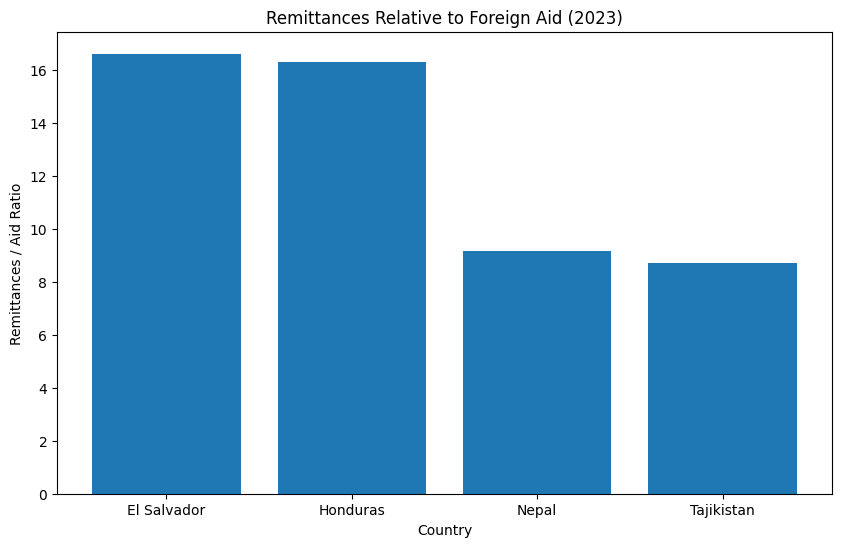

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    latest["country"],
    latest["remittance_to_aid_ratio"]
)

plt.title("Remittances Relative to Foreign Aid (2023)")
plt.ylabel("Remittances / Aid Ratio")
plt.xlabel("Country")

plt.savefig('images/remittance_to_foreign_aid.png', dpi=150, bbox_inches='tight')
plt.show()

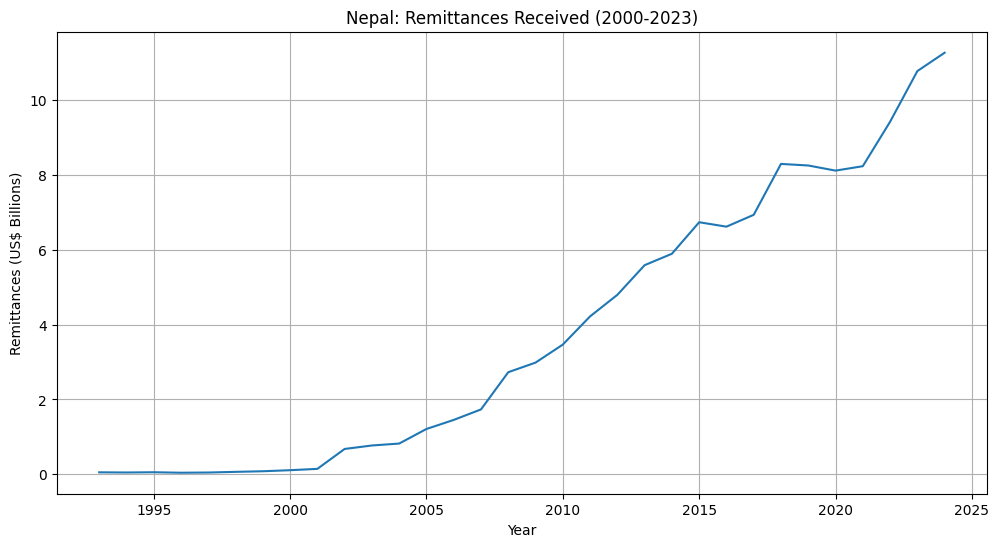

In [128]:
# Nepal remittances over time

nepal_remit = remit_df[
    remit_df["country"] == "Nepal"
].copy()

nepal_remit = nepal_remit.sort_values("year")

plt.figure(figsize=(12,6))

plt.plot(
    nepal_remit["year"],
    nepal_remit["remittances_usd"] / 1e9
)

plt.title("Nepal: Remittances Received (2000-2023)")
plt.xlabel("Year")
plt.ylabel("Remittances (US$ Billions)")
plt.grid(True)

plt.savefig('images/nepal_remittances_received.png', dpi=150, bbox_inches='tight')
plt.show()

In [129]:
nepal = pd.merge(
    remit_df,
    aid_df,
    on=["country", "year"],
    how="inner"
)

nepal = nepal[
    nepal["country"] == "Nepal"
].copy()

nepal = nepal.sort_values("year")

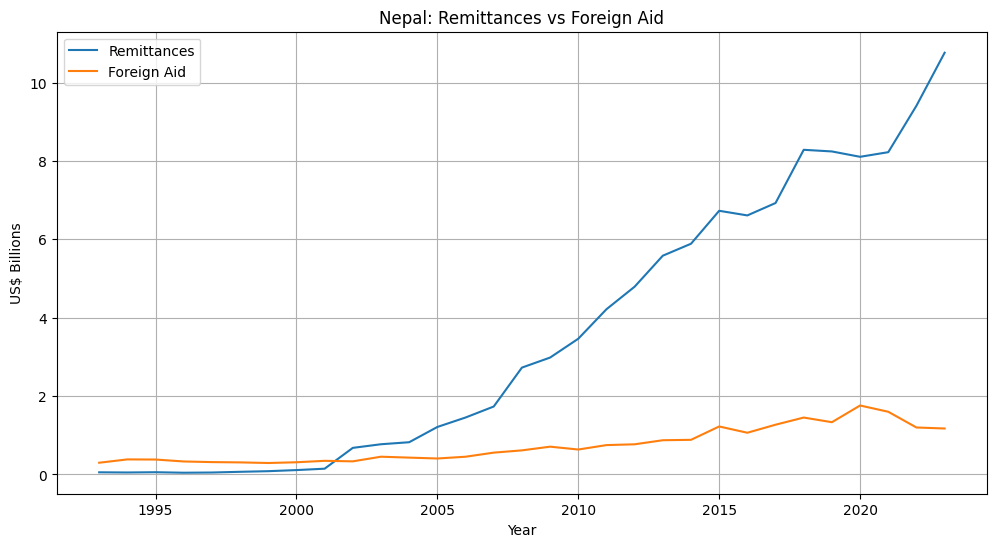

In [130]:
plt.figure(figsize=(12,6))

plt.plot(
    nepal["year"],
    nepal["remittances_usd"] / 1e9,
    label="Remittances"
)

plt.plot(
    nepal["year"],
    nepal["aid_usd"] / 1e9,
    label="Foreign Aid"
)

plt.title("Nepal: Remittances vs Foreign Aid")
plt.xlabel("Year")
plt.ylabel("US$ Billions")

plt.legend()
plt.grid(True)

plt.savefig('images/nepal_remittances_vs_aid.png', dpi=150, bbox_inches='tight')
plt.show()

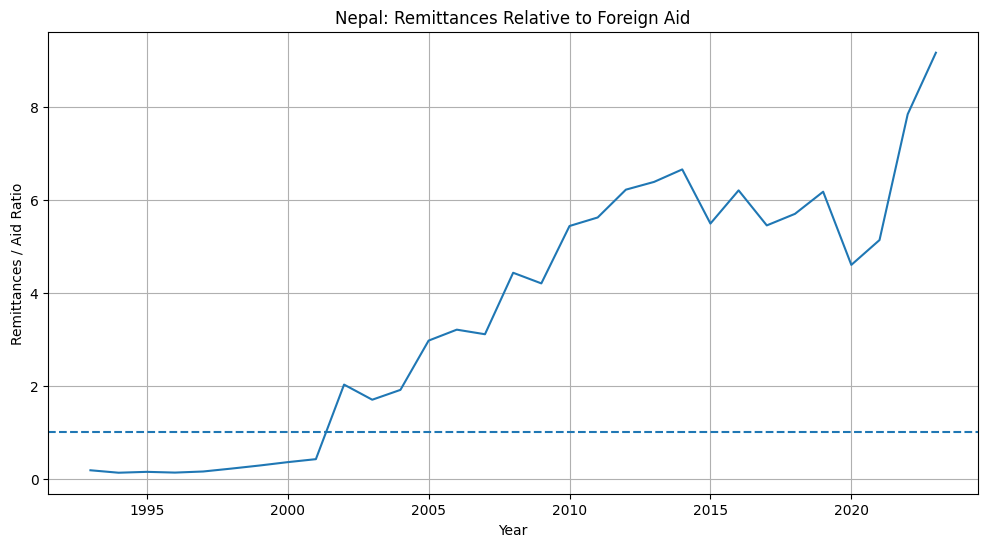

In [131]:
nepal["ratio"] = (
    nepal["remittances_usd"] /
    nepal["aid_usd"]
)

plt.figure(figsize=(12,6))

plt.plot(
    nepal["year"],
    nepal["ratio"]
)

plt.axhline(
    y=1,
    linestyle="--"
)

plt.title("Nepal: Remittances Relative to Foreign Aid")
plt.xlabel("Year")
plt.ylabel("Remittances / Aid Ratio")

plt.grid(True)

plt.savefig('images/nepal_remittances_relative_to_aid.png', dpi=150, bbox_inches='tight')
plt.show()

In [132]:
countries = [
    "Nepal",
    "Honduras",
    "El Salvador",
    "Tajikistan"
]

comparison = pd.merge(
    remit_df,
    aid_df,
    on=["country", "year"],
    how="inner"
)

comparison = comparison[
    (comparison["country"].isin(countries))
    &
    (comparison["year"] == 2023)
].copy()

comparison["ratio"] = (
    comparison["remittances_usd"] /
    comparison["aid_usd"]
)

comparison = comparison.sort_values(
    "ratio",
    ascending=False
)

comparison

,country,year,remittances_usd,aid_usd,ratio
3871,El Salvador,2023,8.286894e+09,4.988104e+08,16.613314
4444,Honduras,2023,8.968206e+09,5.507666e+08,16.283134
5684,Nepal,2023,1.076441e+10,1.173137e+09,9.175752
6843,Tajikistan,2023,4.633754e+09,5.307999e+08,8.729758


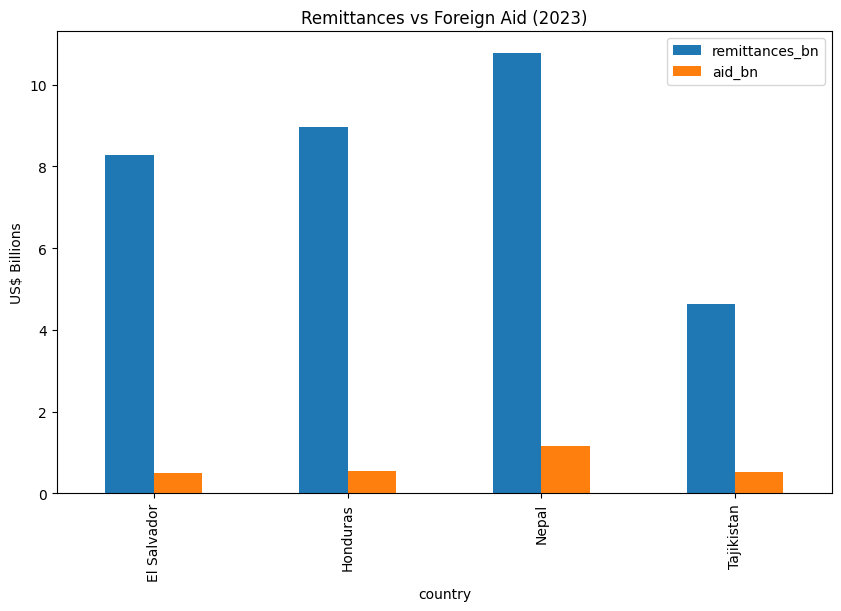

In [133]:
comparison_plot = comparison.copy()

comparison_plot["remittances_bn"] = (
    comparison_plot["remittances_usd"] / 1e9
)

comparison_plot["aid_bn"] = (
    comparison_plot["aid_usd"] / 1e9
)

comparison_plot.set_index("country")[
    ["remittances_bn", "aid_bn"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Remittances vs Foreign Aid (2023)")
plt.ylabel("US$ Billions")

plt.savefig('images/remittances_vs_foreign_aid_total.png', dpi=150, bbox_inches='tight')
plt.show()

# Migration, Remittances and Development Finance

## Research Question

To what extent do remittances act as an alternative source of development finance in remittance-dependent developing economies?

## Introduction

Remittances are financial transfers sent by migrants to their home countries. In many developing economies, remittances represent a substantial share of national income and can often exceed official development assistance (foreign aid).

This project investigates which countries are most dependent on remittances and explores whether migration acts as an informal mechanism of international development by transferring resources directly to households in migrants' countries of origin.

## Importing Libraries

The following libraries are used throughout the project:

* pandas – data manipulation and analysis
* requests – accessing the World Bank API
* matplotlib – data visualisation

## Data Sources

The project uses data from the World Bank API.

### Remittances as a Percentage of GDP

Indicator:

BX.TRF.PWKR.DT.GD.ZS

This measures personal remittances received as a percentage of GDP and is used to identify the countries most dependent on remittance inflows.

### Personal Remittances Received (Current US$)

Indicator:

BX.TRF.PWKR.CD.DT

This measures the total value of remittances received and is used to analyse long-term trends and compare remittances with foreign aid.

### Official Development Assistance (Current US$)

Indicator:

DT.ODA.ODAT.CD

This measures net official development assistance received and is used to compare aid flows with remittance inflows.

## Data Cleaning

The datasets contain missing values and store years as strings. Missing observations were removed and year variables were converted into numeric format to enable time-series analysis.

## Results

The analysis identified several countries that are highly dependent on remittances. In 2023, countries such as Tonga, Tajikistan, Nepal, Honduras and El Salvador received remittances equivalent to a substantial share of GDP.

A case study of Nepal showed that remittance inflows increased significantly between 2000 and 2023. Over the same period, remittances grew faster than official development assistance and became a major source of external finance.

Comparisons across Nepal, Honduras, El Salvador and Tajikistan indicate that remittances frequently exceed foreign aid. In several cases, migrants collectively transfer several times more money to their home countries than is provided through official aid programmes.

## Discussion

The findings suggest that migration may act as an informal mechanism of international development. Unlike foreign aid, remittances are private transfers that flow directly to households and can be used according to local needs and priorities.

The results also suggest that remittances have become an increasingly important source of development finance in a number of developing economies. In some countries, remittance inflows now exceed the value of official development assistance by a considerable margin.

However, remittance dependence may also create vulnerabilities. Economies that rely heavily on migrant transfers can become exposed to economic downturns in destination countries, as remittance inflows may fall if migrants lose employment or experience lower earnings abroad.

Another potential drawback is brain drain. Brain drain refers to the emigration of skilled and educated workers from their home country to seek better opportunities elsewhere. This can reduce the supply of human capital available domestically, particularly in sectors such as healthcare, education and engineering. As a result, countries may lose productive workers whose skills could have contributed to economic growth, innovation and the provision of public services.

The findings of this project therefore highlight only one aspect of migration's economic impact. While remittances appear to provide substantial financial benefits, a full assessment of migration would also need to consider the costs associated with the loss of skilled labour.

## Conclusion

Overall, the evidence indicates that remittances are a significant source of external finance and, in many remittance-dependent economies, exceed official foreign aid inflows. While remittances should not be viewed as a complete substitute for development assistance, they appear to play an increasingly important role in supporting economic development and household welfare in developing countries.

## Further Research

This project focuses on remittances as a potential benefit of migration. Future research could examine the wider economic effects of emigration by analysing indicators related to human capital and productivity.

For example, a follow-up study could investigate whether countries experiencing high levels of skilled emigration subsequently experience slower growth in GDP per capita, lower productivity, shortages in skilled occupations, or reduced investment in sectors such as healthcare and education. Comparing these effects with the benefits generated through remittances would provide a more comprehensive assessment of migration's overall impact on economic development.